# Basic of Pytorch

In [1]:
import torch
x=torch.rand(4,3)
print(x)

import numpy as np
print(torch.Tensor(np.array([[1,2],[3,4]])))
print (torch.Tensor([True, False]))
print(torch.Tensor((1,2,3,4,5)))
print(torch.Tensor([i for i in range(10)]))


#Create special tensor
x=torch.zeros(4,3, dtype=torch.long)
print(x)
x=torch.ones(4,3, dtype=torch.double)
print(x)
x=torch.randn_like(x,dtype=torch.float)
print(x)
import torch
import torchvision

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

/home/ma-user/anaconda3/envs/PyTorch-1.8/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor([[0.7879, 0.0025, 0.6197],
        [0.2086, 0.0541, 0.9862],
        [0.8638, 0.4408, 0.5359],
        [0.9355, 0.3360, 0.3591]])
tensor([[1., 2.],
        [3., 4.]])
tensor([1., 0.])
tensor([1., 2., 3., 4., 5.])
tensor([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])
tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)
tensor([[-0.3655,  1.3352,  0.3392],
        [ 1.9693,  0.5402,  0.1808],
        [-0.0220, -0.3069, -3.1861],
        [-1.3307, -1.0130,  0.6421]])
Torch version: 1.13.1+cpu
Torchvision version: 0.14.1+cpu
CUDA available: False


/home/ma-user/anaconda3/envs/PyTorch-1.8/lib/python3.7/site-packages/requests/__init__.py:104: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (5.2.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  RequestsDependencyWarning)


### Tensor Attributes and methods

In [2]:
x=torch.Tensor(np.array([[1,2],[3,4]]))
print(x.shape)
print(x.size())
print(x.dim())
print(x.device)
print(x.dtype)

print(x.reshape(4,1))
x=x.unsqueeze(2)#add dimension
print(x.shape)
x=x.squeeze(2)
print(x.shape)
print(x.flatten)
x.to (x.device)
print(torch.__version__)

torch.Size([2, 2])
torch.Size([2, 2])
2
cpu
torch.float32
tensor([[1.],
        [2.],
        [3.],
        [4.]])
torch.Size([2, 2, 1])
torch.Size([2, 2])
<built-in method flatten of Tensor object at 0x7f440cf4c6b0>
1.13.1+cpu


### Loading the dataset

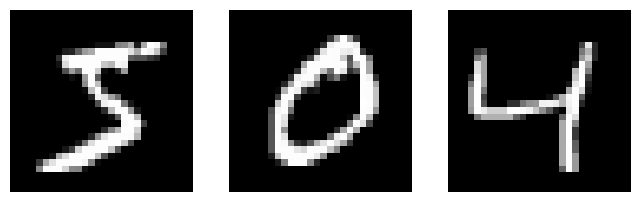

In [3]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Load MNIST dataset
train_dataset = datasets.MNIST(
    root='./MNIST',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Create figure
plt.figure(figsize=(8, 8))

# Print first 3 images
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(train_dataset.data[i], cmap='gray')
    plt.axis('off')

plt.show()

### Use Image Folder to Load dataset

In [4]:
import torchvision
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train = torchvision.datasets.ImageFolder(
    "./flower_photos/train/",
    transform=transform
)

#check the dataset types
print("Dataset types")
print(train.classes)
print(train.class_to_idx)
print("Dataset samples")
print(train.samples[0])
print("Image data format")
print(train.extensions[0])


Dataset types
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
{'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
Dataset samples
('./flower_photos/train/daisy/100080576_f52e8ee070_n.jpg', 0)
Image data format
.jpg


### Visualize the data

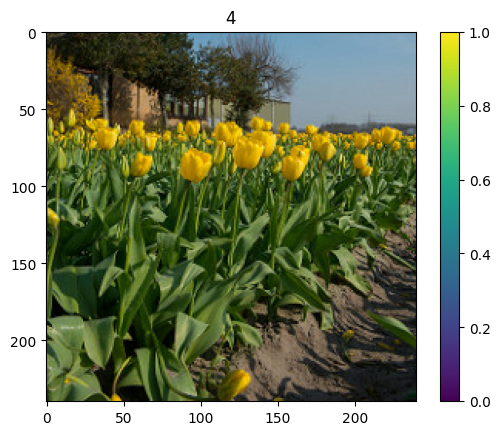

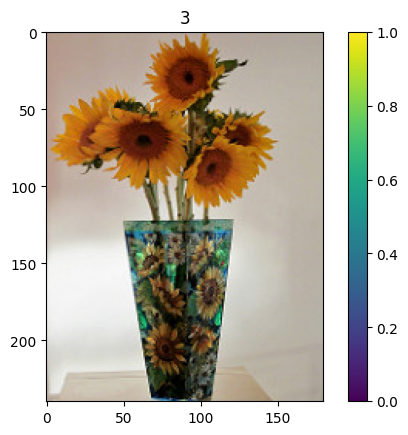

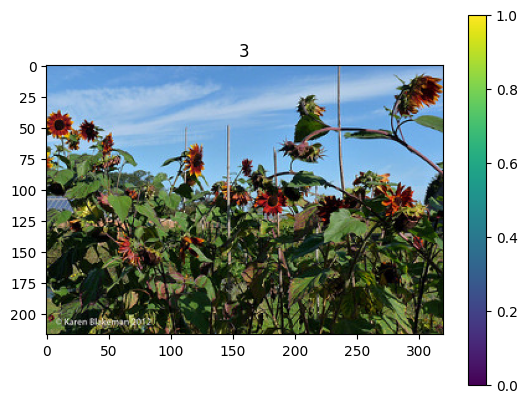

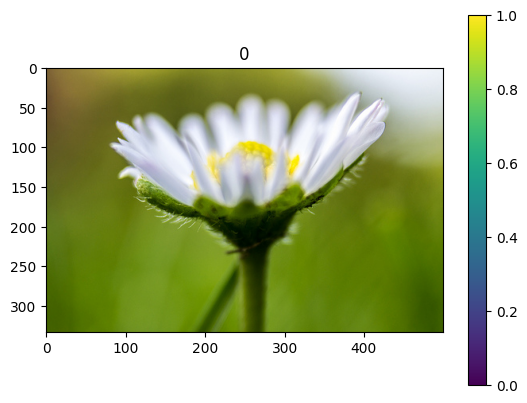

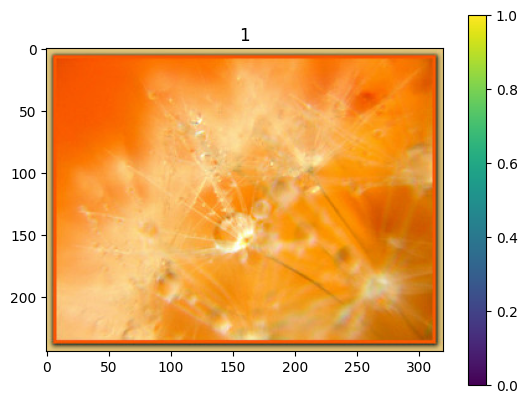

In [5]:
#Display the loaded image data
import random

for i in range(5):
    plt.figure()
    random.seed=2
    num=random.randint(0,3000)
    plt.imshow(train[num][0].permute(1,2,0))#train[num] return a tuple containing data and the category
    plt.title(train[num][1])
    plt.colorbar()
    plt.grid(False)
plt.show()    
    

### Customize dataset

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Files already downloaded and verified
Files already downloaded and verified


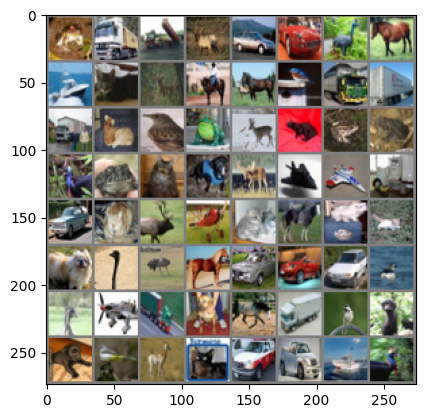

In [7]:


# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Load dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=False,
    num_workers=0   # IMPORTANT
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False,
    num_workers=0   # IMPORTANT
)

# Display images
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow = torchvision.utils.make_grid(images)
imshow = imshow * 0.5 + 0.5  # unnormalize
imshow = imshow.numpy().transpose((1,2,0))

plt.imshow(imshow)
plt.show()

### Define instantiate a network structure class

In [9]:
import torch.nn.functional as F

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = torch.tanh(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x
    
#Instantiate the LeNet network
net =LeNet()
net.parameters

<bound method Module.parameters of LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)>

### Define the loss function and optimizer

In [10]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(net.parameters(),lr=0.001, momentum=0.9)


### Define the training process

In [12]:
if os.path.isfile("cifar10.pth"):
    net.load_state_dict(torch.load("cifar10.pth"))
loss_history=[]
    
for epoch in range(50):
    running_loss=0.0
    for i,data in enumerate(trainloader,0):
        inputs, labels=data
        optimizer.zero_grad()
        
        outputs=net(inputs)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss +=loss.item()
        if i%200==199:
            print(f'[Epoch:{epoch+1}, Bath:{i+1}] loss:{running_loss/200:.3f}')
            running_loss=0.0
            
        #Record the loss value
        loss_history.append(loss.item())
print('Finished Training!')        
    
    

[Epoch:2, Bath:200] loss:1.977
[Epoch:2, Bath:400] loss:1.947
[Epoch:2, Bath:600] loss:1.915
[Epoch:3, Bath:200] loss:1.830
[Epoch:3, Bath:400] loss:1.781
[Epoch:3, Bath:600] loss:1.740
[Epoch:4, Bath:200] loss:1.659
[Epoch:4, Bath:400] loss:1.627
[Epoch:4, Bath:600] loss:1.607
[Epoch:5, Bath:200] loss:1.542
[Epoch:5, Bath:400] loss:1.521
[Epoch:5, Bath:600] loss:1.517
[Epoch:6, Bath:200] loss:1.464
[Epoch:6, Bath:400] loss:1.455
[Epoch:6, Bath:600] loss:1.465
[Epoch:7, Bath:200] loss:1.416
[Epoch:7, Bath:400] loss:1.408
[Epoch:7, Bath:600] loss:1.424
[Epoch:8, Bath:200] loss:1.377
[Epoch:8, Bath:400] loss:1.367
[Epoch:8, Bath:600] loss:1.385
[Epoch:9, Bath:200] loss:1.344
[Epoch:9, Bath:400] loss:1.332
[Epoch:9, Bath:600] loss:1.351
[Epoch:10, Bath:200] loss:1.314
[Epoch:10, Bath:400] loss:1.301
[Epoch:10, Bath:600] loss:1.320
[Epoch:11, Bath:200] loss:1.286
[Epoch:11, Bath:400] loss:1.273
[Epoch:11, Bath:600] loss:1.292
[Epoch:12, Bath:200] loss:1.260
[Epoch:12, Bath:400] loss:1.246


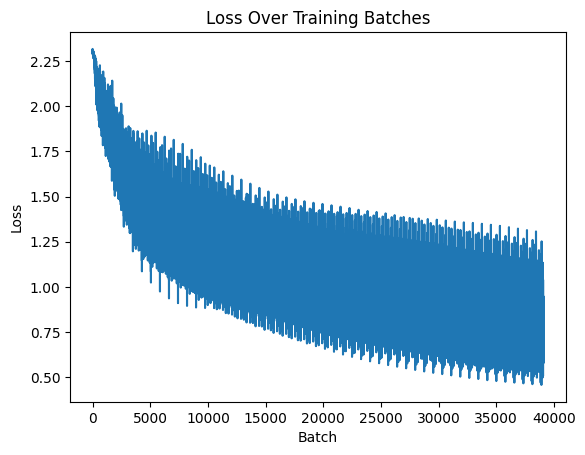

In [13]:
#Draw the loss curve
plt.plot(loss_history)
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Loss Over Training Batches')
plt.show()

In [14]:
# Test the performance of the network with the test set
correct=0
total=0
with torch.no_grad():
    for data in testloader:
        images,labels=data
        outputs=net(images)
        _,predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
        
print(f'Accuracy of the network on the 10000 test test images :{100*correct/total:.2f}%')        

Accuracy of the network on the 10000 test test images :64.54%
